#Imports and Reading Dataset

In [ ]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pickle
from sklearn.preprocessing import RobustScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from shaphypetune import BoostRFE, BoostBoruta,BoostRFA
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV


In [ ]:
df= pd.read_csv("MalMem2022.csv")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.shape


def clean_category_name(category):
    parts = category.split('-')
    if parts[0] == 'Benign':
        return 'Benign'
    elif parts[0] == 'Attack':
        # Remove the Attack prefix and everything after the first number/hex sequence
        if len(parts) > 1:
            return '-'.join(parts[1:])
        else:
            return category
    else:
        # Assume the format is AttackType-Hash-Number.raw
        # We want to keep the AttackType only
        if len(parts) > 0:
            return parts[0]
        else:
            return category

df['Category'] = df['Category'].apply(clean_category_name)
df = df.rename(columns={'Category': 'label'})

df['label'].value_counts()

remove = ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services','Class']


df = df.drop(columns=remove)
df

,label,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric
0,Benign,45,17,10.555556,202.844444,1694,38.500000,9129,212.302326,670,...,138,389,221,26,24,116,121,87,0,8
1,Benign,47,19,11.531915,242.234043,2074,44.127660,11385,242.234043,840,...,138,392,222,26,24,118,122,87,0,8
2,Benign,40,14,14.725000,288.225000,1932,48.300000,11529,288.225000,1050,...,137,395,222,26,27,118,120,88,0,8
3,Benign,32,13,13.500000,264.281250,1445,45.156250,8457,264.281250,630,...,138,395,222,26,27,118,120,88,0,8
4,Benign,42,16,11.452381,281.333333,2067,49.214286,11816,281.333333,908,...,138,392,222,26,24,118,124,87,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58591,Ransomware,37,15,10.108108,215.486487,1453,39.270270,7973,215.486487,630,...,138,389,221,26,24,116,120,86,0,8
58592,Ransomware,37,14,9.945946,190.216216,1347,36.405405,7038,190.216216,603,...,138,389,221,26,24,116,116,88,0,8
58593,Ransomware,38,15,9.842105,210.026316,1448,38.105263,7982,215.729730,624,...,138,389,221,26,24,116,120,88,0,8
58594,Ransomware,37,15,10.243243,215.513513,1452,39.243243,7974,215.513513,632,...,138,389,221,26,24,116,120,87,0,8


In [ ]:
df= pd.read_csv("Downloads/NF-UNSW-NB15-v3.csv")


df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df = df.rename(columns={'Attack': 'label'})
df.shape

remove = ['Label', 'L4_SRC_PORT', 'L4_DST_PORT','IPV4_SRC_ADDR', 'IPV4_DST_ADDR','FTP_COMMAND_RET_CODE']    #MULTI

df = df.drop(columns=remove)
df = df.rename(columns={'Attack': 'label'})
df = df.rename(columns={'Label': 'label'})

df

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,DNS_TTL_ANSWER,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,label
0,1424242193040,1424242193043,17,5.0,146,2,178,2,0,0,...,60,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,6,11.0,4704,28,2976,28,27,27,...,0,0,91,12,19,0,90,12,19,Benign
2,1424242190649,1424242193109,6,37.0,13662,238,548216,438,27,27,...,0,0,1843,10,119,0,1843,5,88,Benign
3,1424242193145,1424242193146,17,5.0,146,2,178,2,0,0,...,60,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,17,5.0,130,2,162,2,0,0,...,60,0,0,0,0,0,0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2365419,1421972723458,1421972723766,6,37.0,31366,42,2566,30,26,26,...,0,0,73,7,21,0,74,10,25,Benign
2365420,1421972723557,1421972723563,6,37.0,2054,22,2478,24,27,27,...,0,0,1,0,0,0,1,0,0,Benign
2365421,1421972723565,1421972723788,6,37.0,8928,14,320,6,27,27,...,0,0,173,16,46,0,174,44,67,Benign
2365422,1421972723758,1421972723759,17,5.0,146,2,178,2,0,0,...,60,0,0,0,0,0,0,0,0,Benign


In [ ]:
X = df.drop('label', axis=1)
y = df['label']

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)
num_class = len(label_encoder.classes_)

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, stratify=y_trainval, test_size=0.1, random_state=42
)

feature_names = X_train.columns.tolist()

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=feature_names)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=feature_names)

results = []
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_val, label=y_val)
dtest= xgb.DMatrix(X_test, label=y_test)


# Functions

In [ ]:
def expected_calibration_error(samples, true_labels, M=5):
    # uniform binning approach with M number of bins
    bin_boundaries = np.linspace(0, 1, M + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    # get max probability per sample i
    confidences = np.max(samples, axis=1)
    # get predictions from confidences (positional in this case)
    predicted_label = np.argmax(samples, axis=1)

    # get a boolean list of correct/false predictions
    accuracies = predicted_label==true_labels

    ece = np.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # determine if sample is in bin m (between bin lower &amp; upper)
        in_bin = np.logical_and(confidences > bin_lower.item(), confidences <= bin_upper.item())
        # can calculate the empirical probability of a sample falling into bin m: (|Bm|/n)
        prob_in_bin = in_bin.mean()

        if prob_in_bin.item() > 0:
            # get the accuracy of bin m: acc(Bm)
            accuracy_in_bin = accuracies[in_bin].mean()
            # get the average confidence of bin m: conf(Bm)
            avg_confidence_in_bin = confidences[in_bin].mean()
            # calculate |acc(Bm) - conf(Bm)| * (|Bm|/n) for bin m and add to the total ECE
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prob_in_bin
    return ece




# --- Evaluation for multiclass ---
def evaluate_model(model, X, y, n_bins=10):
    # Ensure X is a pandas DataFrame for prediction/shap
    if not isinstance(X, pd.DataFrame):
         pass # Keep the original logic for now, and fix calls later

    y_pred  = model.predict(X)
    proba    = model.predict_proba(X)
    p_max    = np.max(proba, axis=1)
    acc      = accuracy_score(y, y_pred)
    prec     = precision_score(y, y_pred, average='macro')
    rec      = recall_score(y, y_pred, average='macro')
    f1       = f1_score(y, y_pred, average='macro')
    # brier_score_loss requires binary targets for binary prediction, or one-hot for multiclass
    # The current implementation calculates brier for prediction correctness (binary 0/1) vs max prob
    # brier    = brier_score_loss((y_pred==y).astype(int), p_max)
    ece = expected_calibration_error( proba,y)
    num_features = X.shape[1]

    return {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1": f1,
        # "Brier": brier,
        "ECE": ece[0],"Features": num_features,
    }


In [ ]:
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / np.sum(e_x, axis=1, keepdims=True)


def evaluate_model_custom(model, X, y, n_bins=10):
    """
    Evaluate model performance with custom metrics.
    Handles both DMatrix and pandas/numpy inputs.

    Args:
        model: Trained XGBoost model
        X: Input features (DMatrix, DataFrame, or numpy array)
        y: True labels
        n_bins: Number of bins for calibration metrics

    Returns:
        Dictionary of evaluation metrics
    """
    # Handle different input types
    if isinstance(X, xgb.DMatrix):
        # Get predictions directly from DMatrix
        proba = model.predict(X)
        X_for_shap = X  # Keep as DMatrix for SHAP if needed
    else:
        # Convert to DMatrix if not already
        dmatrix = xgb.DMatrix(X)
        proba = model.predict(dmatrix)
        X_for_shap = X  # Keep original for SHAP if needed

    # Calculate predictions and max probabilities
    y_pred = np.argmax(proba, axis=1)
    p_max = np.max(proba, axis=1)

    # Calculate metrics
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro')
    rec = recall_score(y, y_pred, average='macro')
    f1 = f1_score(y, y_pred, average='macro')

    # Brier score calculation (handles binary correctness)
    brier = brier_score_loss((y_pred == y).astype(int), p_max)

    # Expected Calibration Error
    ece = expected_calibration_error(proba, y)

    # Get feature count (handle DMatrix case)
    if isinstance(X, xgb.DMatrix):
        try:
            num_features = X.num_col()
        except:
            num_features = proba.shape[1]  # Fallback to num classes if feature count unavailable
    else:
        num_features = X.shape[1]

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "Brier": brier,
        "ECE": ece[0],
        "Features": num_features
    }

In [ ]:
def custom_softmax_brier_obj(alpha=0.5, num_class=8):
    """
    Updated custom multiclass loss that complies with XGBoost 2.1.0+ shape requirements
    """
    def objective(preds, dtrain):
        labels = dtrain.get_label().astype(int)
        preds = preds.reshape(-1, num_class)
        probs = softmax(preds)

        # One-hot encode labels
        y_onehot = np.zeros_like(probs)
        y_onehot[np.arange(len(labels)), labels] = 1

        # Gradients
        grad_ce = probs - y_onehot
        grad_brier = 2 * (probs - y_onehot)

        # Hessians
        hess_ce = probs * (1 - probs)
        hess_brier = 2 * probs * (1 - probs)

        # Combine - now returning unflattened arrays
        grad = alpha * grad_ce + (1 - alpha) * grad_brier
        hess = alpha * hess_ce + (1 - alpha) * hess_brier

        return grad, hess  # No more reshape(-1)

    return objective

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
import xgboost as xgb
import numpy as np
from xgboost import XGBClassifier

class XGBClassifierWithCustomLoss(XGBClassifier):
    def __init__(self, alpha=0.5, num_class=8, n_estimators=100, **kwargs):
        super().__init__(n_estimators=n_estimators, **kwargs)
        self.alpha = alpha
        self.num_class = num_class
        self._custom_obj = custom_softmax_brier_obj(alpha, num_class)
        self.evals_result_ = {}  # Initialize evals_result_
        self._classes = None     # Initialize classes_
        self.n_classes_ = None   # Initialize n_classes_

    @property
    def classes_(self):
        return self._classes

    def fit(self, X, y, eval_set=None, early_stopping_rounds=None, **kwargs):
        # Store classes information
        self._classes = np.unique(y)
        self.n_classes_ = len(self._classes)

        # Update num_class if not provided or if different from actual classes
        if self.num_class != self.n_classes_:
            self.num_class = self.n_classes_
            # Recreate custom objective with updated num_class
            self._custom_obj = custom_softmax_brier_obj(self.alpha, self.num_class)

        # Convert to XGBoost DMatrix format
        dtrain = xgb.DMatrix(X, label=y)

        # Handle eval_set
        evals = []
        if eval_set is not None:
            if isinstance(eval_set[0], (tuple, list)) and len(eval_set[0]) == 2:
                X_val, y_val = eval_set[0]
                dvalid = xgb.DMatrix(X_val, label=y_val)
                evals = [(dvalid, 'eval')]

        # Get and update parameters
        params = self.get_xgb_params()
        params.update({
            'num_class': self.num_class,
            'objective': 'multi:softprob'  # Need to specify some objective
        })

        # Ensure n_estimators is properly passed
        num_boost_round = kwargs.pop('num_boost_round', self.n_estimators)

        # Initialize evals_result
        evals_result = {}

        # Train using the low-level API with custom objective
        self._Booster = xgb.train(
            params,
            dtrain,
            num_boost_round=num_boost_round,
            obj=self._custom_obj,
            evals=evals,
            early_stopping_rounds=early_stopping_rounds,
            evals_result=evals_result,
            **kwargs
        )

        # Store evaluation results
        self.evals_result_ = evals_result

        # Store feature names if available
        if hasattr(X, 'columns'):
            self._feature_names = list(X.columns)

        return self

    def predict_proba(self, X, **kwargs):
        # Use parent class implementation which handles DMatrix conversion
        return super().predict_proba(X, **kwargs)

In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
from datetime import date
today = date.today()

def three_way_cv_comparison(X, y, n_splits=5, base_seed=42,dataset="Malmem22"):
    """
    Performs 3-way split CV comparing all 4 methods with:
    - 70% train, 10% validation, 20% test per fold
    - Finds optimal alpha for each fold using validation set
    - All methods evaluated on the same test sets
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    num_class = len(np.unique(y))
    results = []
    all_features_data = []

    for fold in range(n_splits):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        current_seed = base_seed + fold

        # First split: 70% train, 30% temp
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, stratify=y, random_state=current_seed
        )

        # Second split: 30% temp -> 10% val (1/3) and 20% test (2/3)
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=current_seed
        )

        print(f"Train: {len(X_train)} ({len(X_train)/len(X):.1%}), "
              f"Val: {len(X_val)} ({len(X_val)/len(X):.1%}), "
              f"Test: {len(X_test)} ({len(X_test)/len(X):.1%})")

        # Convert to DMatrix for custom objective
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)
        dtest = xgb.DMatrix(X_test, label=y_test)

        # ===== Find best alpha for this fold =====
        print("\nFinding optimal alpha for this fold...")
        alpha_results = []
        for alpha in np.arange(1.0, 0.0, -0.01):
            model = xgb.train(
                {
                    'num_class': num_class,
                    'objective': 'multi:softprob',
                    'seed': current_seed
                },
                dtrain,
                num_boost_round=100,
                obj=custom_softmax_brier_obj(alpha=alpha, num_class=num_class),
                evals=[(dval, 'val')],
                early_stopping_rounds=20,
                verbose_eval=False
            )
            res = evaluate_model_custom(model, dval, y_val)
            res['Alpha'] = alpha
            alpha_results.append(res)

        alpha_df = pd.DataFrame(alpha_results)
        best_alpha = alpha_df.loc[alpha_df['ECE'].idxmin(), 'Alpha']
        print(f"Best alpha for fold {fold+1}: {best_alpha:.2f}")

        # ===== 1. Baseline XGBoost (Uncalibrated) =====
        print("\n[1/6] Baseline XGBoost (Uncalibrated)")
        xgb_model = XGBClassifier(
            objective='multi:softprob',
            random_state=current_seed,
            eval_metric='mlogloss'
        )
        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        base_res = evaluate_model(xgb_model, X_test, y_test,n_bins=10)
        base_res.update({'Model': 'Uncalibrated Baseline', 'Fold': fold+1})

        # ===== 2. Calibrated XGBoost =====
        print("\n[2/6] Calibrated XGBoost (Isotonic)")
        calibrated_clf_iso = CalibratedClassifierCV(estimator=xgb_model, method='isotonic', cv=5)
        calibrated_clf_iso.fit(X_train, y_train)
        res_iso = evaluate_model(calibrated_clf_iso, X_test, y_test, n_bins=10)
        res_iso["Model"] = "Calibrated Isotonic"

        # ===== 3. Baseline RFE XGBoost =====
        print("\n[3/6] RFE with Standard XGBoost")
        rfe = BoostRFE(
            estimator=XGBClassifier(
                objective='multi:softprob',
                random_state=current_seed,
                eval_metric='mlogloss'
            ),
            min_features_to_select=1,
            step=1,
            importance_type='shap_importances'
        )
        rfe.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        X_test_rfe = rfe.transform(X_test)
        selected_features_names = X.columns[rfe.support_].tolist()
        print("Selected Features RFE:", selected_features_names)

        rfe_res = evaluate_model(rfe.estimator_, X_test_rfe, y_test,n_bins=10)
        rfe_res.update({
            'Model': 'Baseline RFE',
            'Fold': fold+1,
        })

        all_features_data.append({
            'Split': fold + 1,
            'Model': 'Baseline RFE',
            'Features': selected_features_names,
            'Num_Features': len(selected_features_names),
            'Alpha': best_alpha
        })

        # ======== RFE with Calibration =========
        print("\n[3.5/6] RFE with Calibration")
        calibrated_rfe = CalibratedClassifierCV(
            estimator=rfe.estimator_,
            method='isotonic',
            cv=5,
        )
        calibrated_rfe.fit(X_train, y_train)
        calib = calibrated_rfe

           # Evaluate — assumes evaluate_model returns a dict with metrics.
        res = evaluate_model(calib, X_test_rfe, y_test, n_bins=10)
        res.update({
            "Model": "Baseline RFE + Calibration",
            "Fold": fold+1,
            "Num_Features": len(selected)
        })

        # ======================================== Adding Custom =============================================

        # ===== 4. Custom Objective =====
        print(f"\n[4/6] Custom Objective (α={best_alpha:.2f})")
        custom_model = xgb.train(
            {
                'num_class': num_class,
                'objective': 'multi:softprob',
                'seed': current_seed
            },
            dtrain,
            num_boost_round=100,
            obj=custom_softmax_brier_obj(alpha=best_alpha, num_class=num_class),
            evals=[(dval, 'val')],
            early_stopping_rounds=20
        )
        custom_res = evaluate_model_custom(custom_model, X_test, y_test)
        custom_res.update({'Model': 'Custom', 'Fold': fold+1, 'Alpha': best_alpha})

        # ===== 5. Calibrated Custom =====
        print(f"\n[5/6] Calibrated with Custom Objective")
        xgbc_custom = XGBClassifierWithCustomLoss(
            alpha=best_alpha,
            num_class=num_class,
            eval_metric='mlogloss',
            random_state=current_seed
        )
        calibrated_custom = CalibratedClassifierCV(
            estimator=xgbc_custom,
            method='isotonic',
            cv=5,
            n_jobs=-1
        )
        calibrated_custom.fit(X_train, y_train)
        res_custom = evaluate_model(calibrated_custom, X_test, y_test, n_bins=10)
        res_custom["Model"] = "Calibrated Custom"

        # ===== 6. Custom RFE =====
        print(f"\n[6/6] RFE with Custom Objective (α={best_alpha:.2f})")
        custom_rfe = BoostRFE(
            estimator=xgbc_custom,
            min_features_to_select=1,
            step=1,
            importance_type='shap_importances'
        )
        custom_rfe.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        X_test_custom_rfe = custom_rfe.transform(X_test)
        selected_features_names = X.columns[custom_rfe.support_].tolist()
        print("Selected Features Custom RFE:", selected_features_names)

        dtest_custom = xgb.DMatrix(X_test_custom_rfe, label=y_test)
        custom_rfe_res = evaluate_model_custom(
            custom_rfe.estimator_.get_booster(),
            dtest_custom,
            y_test
        )
        custom_rfe_res.update({
            'Model': 'Custom RFE',
            'Fold': fold+1,
            'Alpha': best_alpha
        })

        all_features_data.append({
            'Split': fold + 1,
            'Model': 'Custom RFE',
            'Features': selected_features_names,
            'Num_Features': len(selected_features_names),
            'Alpha': best_alpha
        })

        # Store all results
        fold_results = pd.DataFrame([base_res, res_iso, rfe_res, res, custom_res, res_custom, custom_rfe_res])
        results.append(fold_results)

        print(f"\nFold {fold+1} Results:")
        print(fold_results[['Model', 'ECE', 'Accuracy', 'Alpha']])

    # Combine all results
    final_df = pd.concat(results).reset_index(drop=True)
    features_df = pd.DataFrame(all_features_data)
    # Calculate averages
    avg_results = final_df.groupby('Model').mean(numeric_only=True)
    print("\n=== Final Average Results ===")
    print(avg_results)

    final_df.to_csv(f"Downloads/Calibration/{dataset}_results.csv")
    features_df.to_csv(f"Downloads/Calibration/{dataset}_features.csv")
    avg_results.to_csv(f"Downloads/Calibration/{dataset}_results_averaged.csv")

    return final_df, avg_results, features_df

#Best Alpha Experimentation

In [ ]:
alpha_start = 1
results_cust = []

while alpha_start > 0:
    alpha_ece_values = []

    # Run each alpha 5 times with different seeds
    for run in range(5):
        alpha = alpha_start
        baseline = xgb.train(
            {
                'num_class': num_class,
                'objective': 'multi:softprob',
                'seed': 42 + run,  # Different seed for each run (42, 43, 44, 45, 46)
                'random_state': 42 + run  # Another common parameter name for random seed
            },
            dtrain,
            num_boost_round=100,
            obj=custom_softmax_brier_obj(alpha=alpha, num_class=num_class),
            evals=[(dvalid, 'valid')],
            early_stopping_rounds=20
        )

        y_pred = np.argmax(baseline.predict(xgb.DMatrix(X_test)), axis=1)
        res_base = evaluate_model_custom(baseline, X_test, y_test)
        alpha_ece_values.append(res_base['ECE'])

    # Calculate mean and std for this alpha
    mean_ece = np.mean(alpha_ece_values)
    std_ece = np.std(alpha_ece_values)

    # Store results
    results_cust.append({
        "Model": f"Custom alpha {alpha_start:.2f}",  # Format to 2 decimal places
        "Mean ECE": mean_ece,
        "Std ECE": std_ece,
        "All ECEs": alpha_ece_values  # Store all values for reference
    })

    alpha_start -= 0.01
    alpha_start = round(alpha_start, 2)  # Avoid floating point precision issues

# Plotting code remains the same as before
alpha_values = [float(res['Model'].split('alpha ')[-1]) for res in results_cust]
mean_ece_values = [res['Mean ECE'] for res in results_cust]
std_ece_values = [res['Std ECE'] for res in results_cust]

res_cus = pd.DataFrame(results_cust)


[0]	valid-mlogloss:1.34125
[1]	valid-mlogloss:1.09599
[2]	valid-mlogloss:0.97395
[3]	valid-mlogloss:0.89220
[4]	valid-mlogloss:0.84292
[5]	valid-mlogloss:0.80669
[6]	valid-mlogloss:0.78068
[7]	valid-mlogloss:0.75669
[8]	valid-mlogloss:0.74179
[9]	valid-mlogloss:0.72547
[10]	valid-mlogloss:0.71197
[11]	valid-mlogloss:0.70545
[12]	valid-mlogloss:0.69520
[13]	valid-mlogloss:0.69099
[14]	valid-mlogloss:0.68780
[15]	valid-mlogloss:0.68090
[16]	valid-mlogloss:0.67698
[17]	valid-mlogloss:0.67315
[18]	valid-mlogloss:0.66973
[19]	valid-mlogloss:0.66611
[20]	valid-mlogloss:0.66059
[21]	valid-mlogloss:0.65715
[22]	valid-mlogloss:0.65584
[23]	valid-mlogloss:0.65589
[24]	valid-mlogloss:0.65385
[25]	valid-mlogloss:0.65037
[26]	valid-mlogloss:0.64845
[27]	valid-mlogloss:0.64608
[28]	valid-mlogloss:0.64425
[29]	valid-mlogloss:0.64333
[30]	valid-mlogloss:0.64215
[31]	valid-mlogloss:0.63987
[32]	valid-mlogloss:0.63919
[33]	valid-mlogloss:0.63849
[34]	valid-mlogloss:0.63632
[35]	valid-mlogloss:0.63533
[3

In [ ]:
alpha = 1

results_cust = []
while alpha >0:
  baseline = xgb.train(
      {
          'num_class': num_class,
          # 'max_depth': 10,
          # 'eta': 0.1,
          'objective': 'multi:softprob',  # <- THIS is critical
      },
      dtrain,
      num_boost_round=100,
      obj=custom_softmax_brier_obj(alpha=alpha, num_class=num_class),
    # feval=multiclass_brier_eval,
      evals=[(dvalid, 'valid')],
      early_stopping_rounds=20
  )

  y_pred = np.argmax(baseline.predict(xgb.DMatrix(X_test)), axis=1)

  # Evaluate on scaled test data DataFrame
  res_base = evaluate_model_custom(baseline, X_test, y_test)
  res_base["Model"] = f"Custom alpha {alpha}"
  results_cust.append(res_base)
  alpha-=0.01

res_cus = pd.DataFrame(results_cust)


Streaming output truncated to the last 5000 lines.
[77]	valid-mlogloss:0.61218
[78]	valid-mlogloss:0.61212
[79]	valid-mlogloss:0.61249
[80]	valid-mlogloss:0.61296
[81]	valid-mlogloss:0.61179
[82]	valid-mlogloss:0.61097
[83]	valid-mlogloss:0.61173
[84]	valid-mlogloss:0.61238
[85]	valid-mlogloss:0.61280
[86]	valid-mlogloss:0.61314
[87]	valid-mlogloss:0.61234
[88]	valid-mlogloss:0.61356
[89]	valid-mlogloss:0.61297
[90]	valid-mlogloss:0.61249
[91]	valid-mlogloss:0.61285
[92]	valid-mlogloss:0.61277
[93]	valid-mlogloss:0.61300
[94]	valid-mlogloss:0.61216
[0]	valid-mlogloss:0.93410
[1]	valid-mlogloss:0.86398
[2]	valid-mlogloss:0.81951
[3]	valid-mlogloss:0.79084
[4]	valid-mlogloss:0.76724
[5]	valid-mlogloss:0.75429
[6]	valid-mlogloss:0.73843
[7]	valid-mlogloss:0.72693
[8]	valid-mlogloss:0.71530
[9]	valid-mlogloss:0.71079
[10]	valid-mlogloss:0.70709
[11]	valid-mlogloss:0.70062
[12]	valid-mlogloss:0.69218
[13]	valid-mlogloss:0.68744
[14]	valid-mlogloss:0.68435
[15]	valid-mlogloss:0.67587
[16]	va

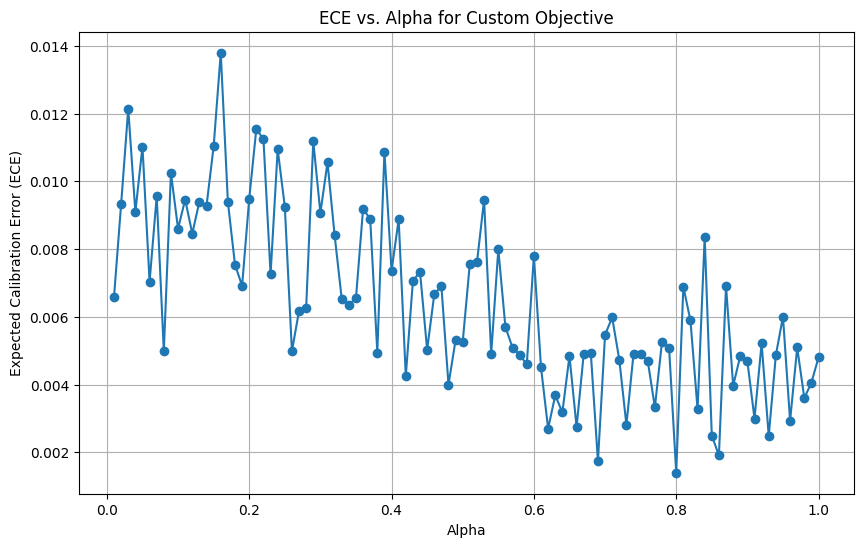

In [ ]:
import matplotlib.pyplot as plt
# Extract alpha values and ECE values

alpha_values = [res['Model'].split('alpha ')[-1] for res in results_cust if 'alpha' in res['Model']]
alpha_values = [float(alpha) for alpha in alpha_values]
ece_values = [res['ECE'] for res in results_cust if 'alpha' in res['Model']]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, ece_values, marker='o', linestyle='-')
plt.xlabel('Alpha')
plt.ylabel('Expected Calibration Error (ECE)')
plt.title('ECE vs. Alpha for Custom Objective')
plt.grid(True)
plt.show()

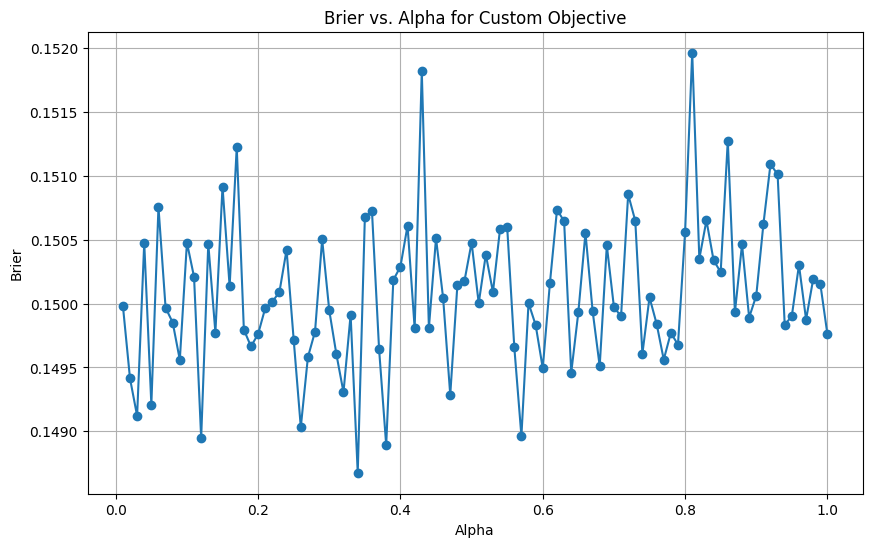

In [ ]:
# Extract alpha values and Brier values
alpha_values = [res['Model'].split('alpha ')[-1] for res in results_cust if 'alpha' in res['Model']]
alpha_values = [float(alpha) for alpha in alpha_values]
brier_values = [res['Brier'] for res in results_cust if 'alpha' in res['Model']]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, brier_values, marker='o', linestyle='-')
plt.xlabel('Alpha')
plt.ylabel('Brier')
plt.title('Brier vs. Alpha for Custom Objective')
plt.grid(True)
plt.show()

# Pipeline and Results

In [ ]:
results, averages,features_df = three_way_cv_comparison(
    X,
    y,
    n_splits=5,
    dataset="MalMem22"
)


=== Fold 1/5 ===
Train: 20508 (70.0%), Val: 2930 (10.0%), Test: 5860 (20.0%)

Finding optimal alpha for this fold...
Best alpha for fold 1: 0.96

[1/6] Baseline XGBoost (Uncalibrated)

[2/6] Calibrated XGBoost (Isotonic)

[3/6] RFE with Standard XGBoost
Selected Features RFE: ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nfile', 'handles.nevent', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_csrss_handles', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_ethread_pool_false_avg', '

In [ ]:
results, averages,features_df = three_way_cv_comparison(
    X,
    y,
    n_splits=5,
    dataset="NF-UNSW-NB-15"
)


=== Fold 1/5 ===
Train: 64332 (70.0%), Val: 9190 (10.0%), Test: 18382 (20.0%)

Finding optimal alpha for this fold...
Best alpha for fold 1: 0.80

[1/6] Baseline XGBoost (Uncalibrated)

[2/6] Calibrated XGBoost (Isotonic)

[3/6] RFE with Standard XGBoost
Selected Features RFE: ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'CLIENT_TCP_FLAGS', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SRC_TO_DST_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_OUT_BYTES', 'ICMP_TYPE']

[4/6] Custom Objective (α=0.80)
[0]	val-mlogloss:1.11758
[1]	val-mlogloss:0.93324
[2]	val-mlogloss:0.83694
[3]	val-mlogloss:0.77446
[4]	val-mlogloss:0.72956
[5]	val-mlogloss:0.69506
[6]	val-mlogloss:0.67409
[7]	val-mlogloss:0.65866
[8]	val-mlogloss:0.64397
[9]	val-mlogloss:0.63221
[10]	val-mlogloss:0.62233
[11]	val-mlogloss:0.61520
[12]	val-mlogloss:0.60388
[13]	val-mlogloss:0.59603
[14]	val-mlogloss:0.59070
[15]	val-mlogloss:0.58380
[16]	val-mlogloss:0.57930
[17]	val-mlogloss:0.57

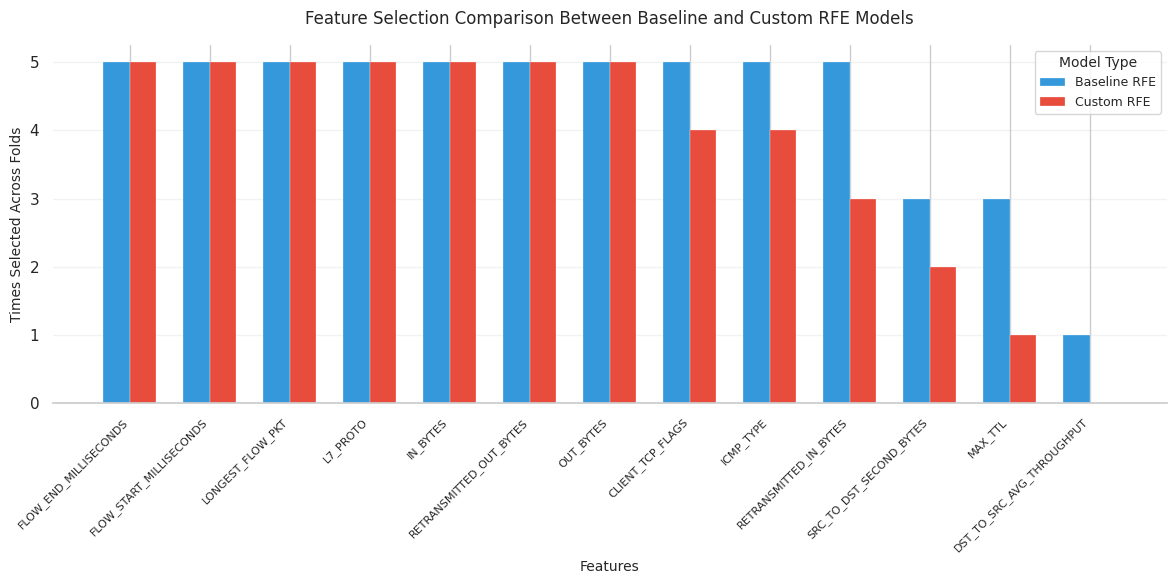

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

features_df = pd.read_csv("NF-UNSW-NB-15_features.csv")
print("Features file read successfully:")

# Load and filter the features DataFrame
rfe_features = features_df[features_df['Model'].isin(['Baseline RFE', 'Custom RFE'])].copy()

def parse_features(cell):
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except:
            return cell.split(',')
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return []

rfe_features['Features'] = rfe_features['Features'].apply(parse_features)

# Convert long format and count feature occurrences
features_long = rfe_features.explode('Features').dropna(subset=['Features'])
feature_counts = features_long.groupby(['Features', 'Model']).size().rename('Count').reset_index()

# Pivot and sort features by total count
pivot = feature_counts.pivot(index='Features', columns='Model', values='Count').fillna(0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False).drop(columns='Total')

# Plotting with reduced horizontal spacing
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Define custom colors
palette = {
    'Baseline RFE': '#3498db',
    'Custom RFE': '#e74c3c'
}

# Define bar width and compressed spacing
bar_width = 0.05
x = np.arange(len(pivot)) * 0.15  # reduced spacing factor

# Draw grouped bars
for i, model in enumerate(pivot.columns):
    offset = (i - 0.5) * bar_width
    ax.bar(x + offset,
           pivot[model],
           width=bar_width,
           label=model,
           color=palette[model],
           edgecolor='white',
           linewidth=0.2)

# X-axis settings
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Labels and title
plt.title('Feature Selection Comparison Between Baseline and Custom RFE Models', fontsize=12, pad=15)
plt.xlabel('Features', fontsize=10)
plt.ylabel('Times Selected Across Folds', fontsize=10)
plt.legend(title='Model Type', frameon=True, fontsize=9, title_fontsize=10)

# Clean style
sns.despine(left=True)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

plt.show()
